In [33]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [34]:
data = pd.read_csv('/Users/vydhyamvishnusai/LOGISTIC_REGRESSION_BY_VISHNUSAI/diabetes.csv') 
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [35]:
data.shape

(768, 9)

In [36]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [37]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [38]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# EDA

In [39]:
data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

<Axes: xlabel='Outcome'>

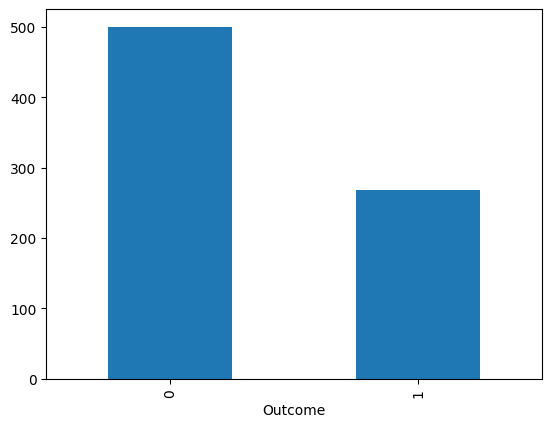

In [40]:
data['Outcome'].value_counts().plot(kind = 'bar')

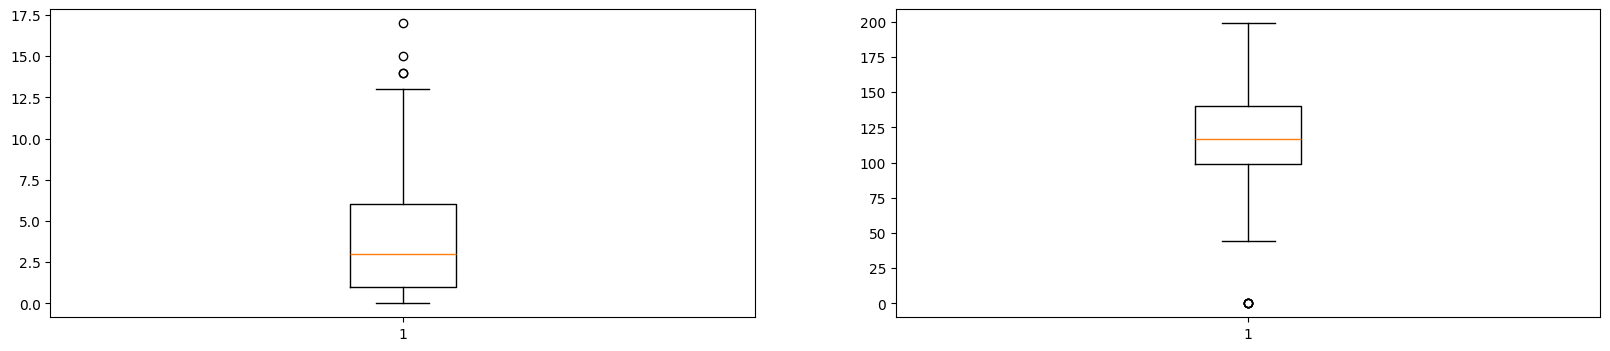

In [41]:
fig = plt.figure(figsize = [20,4]) 
plt.subplot(1,2,1)
plt.boxplot(x = 'Pregnancies', data = data ) 
plt.subplot(1,2,2)
plt.boxplot(x = 'Glucose', data = data) 
plt.show()


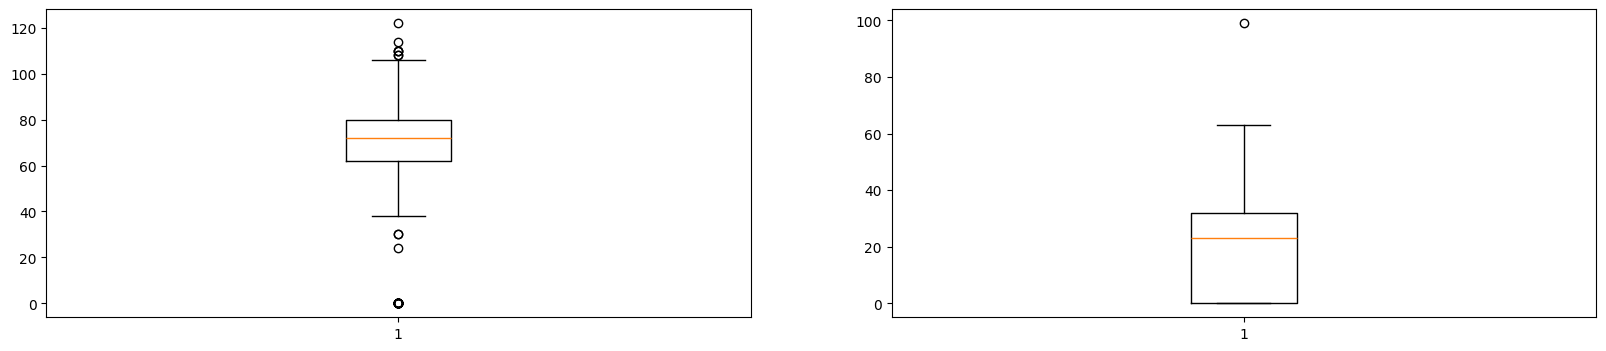

In [42]:
fig = plt.figure(figsize = [20,4]) 
plt.subplot(1,2,1)
plt.boxplot(x = 'BloodPressure', data = data ) 
plt.subplot(1,2,2)
plt.boxplot(x = 'SkinThickness', data = data) 
plt.show()


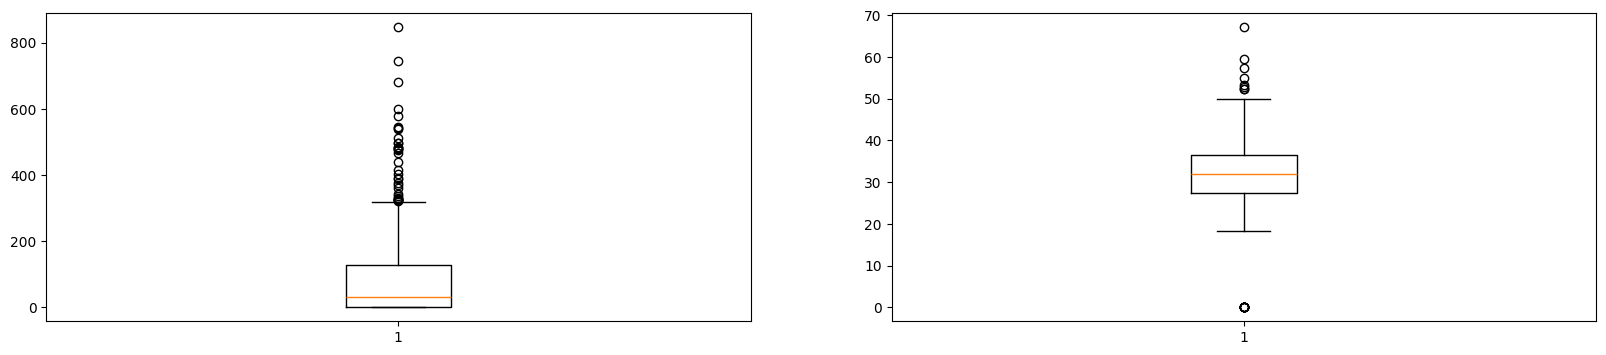

In [43]:
fig = plt.figure(figsize = [20,4]) 
plt.subplot(1,2,1)
plt.boxplot(x = 'Insulin', data = data ) 
plt.subplot(1,2,2)
plt.boxplot(x = 'BMI', data = data) 
plt.show()


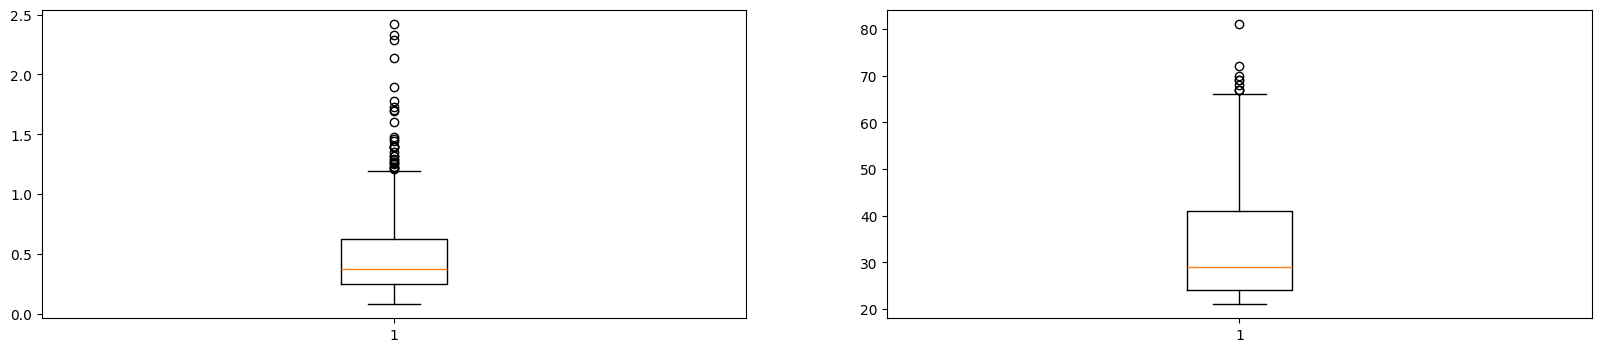

In [44]:
fig = plt.figure(figsize = [20,4]) 
plt.subplot(1,2,1)
plt.boxplot(x = 'DiabetesPedigreeFunction', data = data ) 
plt.subplot(1,2,2)
plt.boxplot(x = 'Age', data = data) 
plt.show()


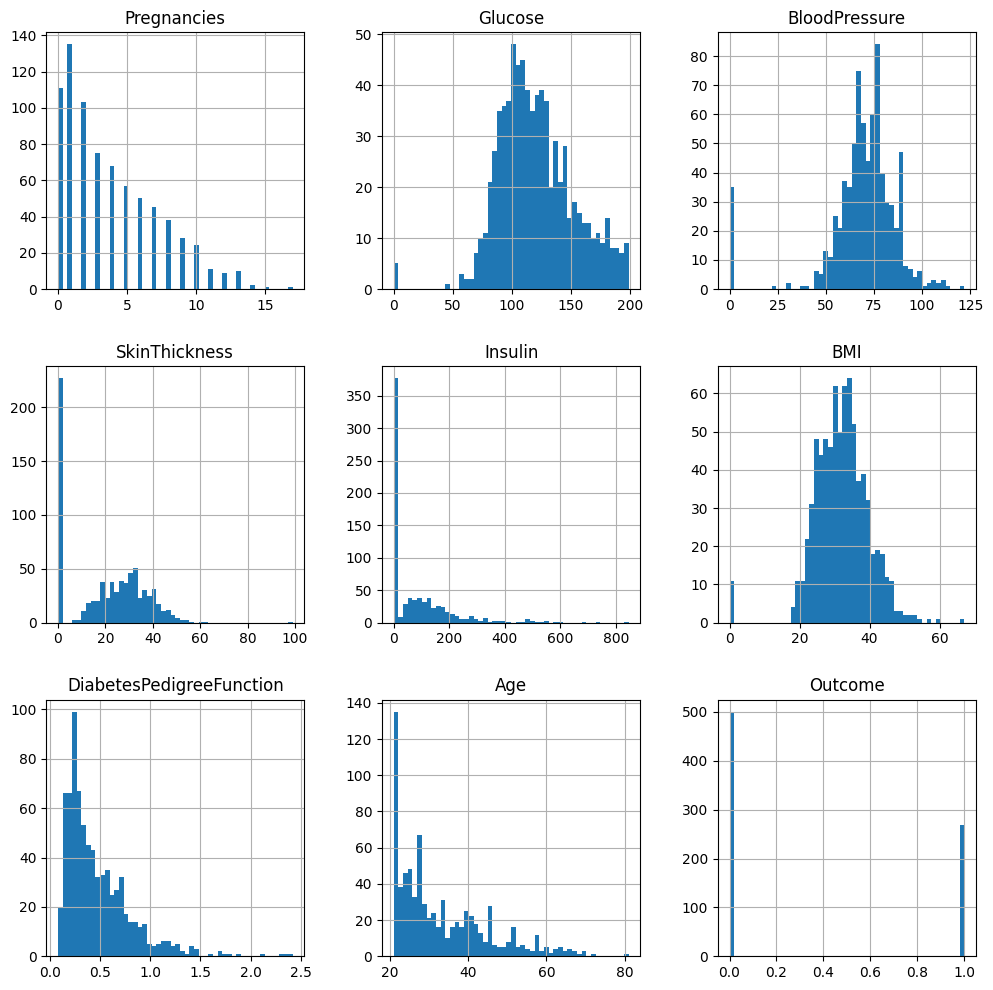

In [45]:
data.hist(bins = 50, figsize = (12,12)) 
plt.show()

# Bivariate Analysis

Text(0.5, 1.0, 'Glucose vs outcome')

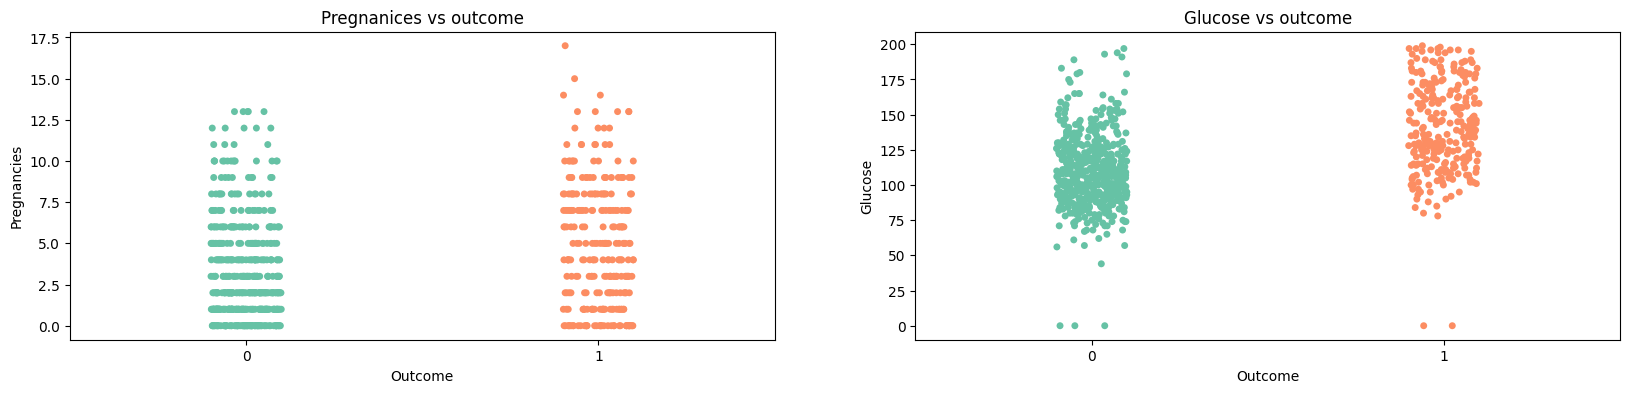

In [46]:
fig = plt.figure(figsize = [20,4]) 

plt.subplot(1,2,1) 
sns.stripplot(x = 'Outcome', y = 'Pregnancies', data = data, jitter = True, palette = "Set2" ) 
plt.title('Pregnanices vs outcome') 

plt.subplot(1,2,2) 
sns.stripplot(x = 'Outcome', y = 'Glucose', data = data, jitter = True, palette = "Set2" ) 
plt.title('Glucose vs outcome') 


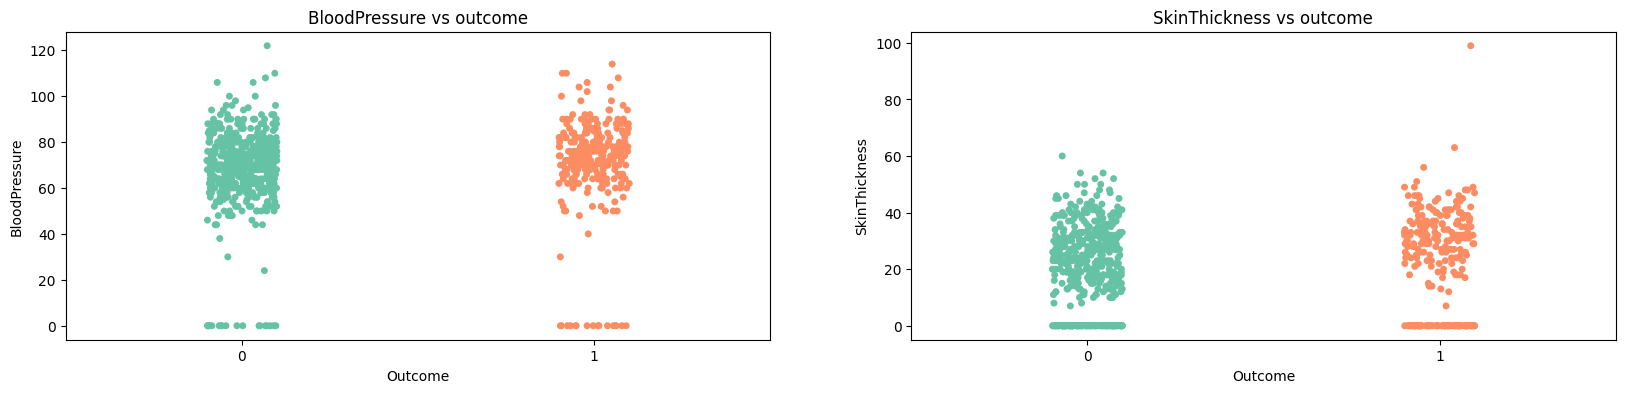

In [47]:
fig = plt.figure(figsize = [20,4]) 

plt.subplot(1,2,1) 
sns.stripplot(x = 'Outcome', y = 'BloodPressure', data = data, jitter = True, palette = "Set2" ) 
plt.title('BloodPressure vs outcome') 

plt.subplot(1,2,2) 
sns.stripplot(x = 'Outcome', y = 'SkinThickness', data = data, jitter = True, palette = "Set2" ) 
plt.title('SkinThickness vs outcome') 
plt.show()

Text(0.5, 1.0, 'Glucose vs outcome')

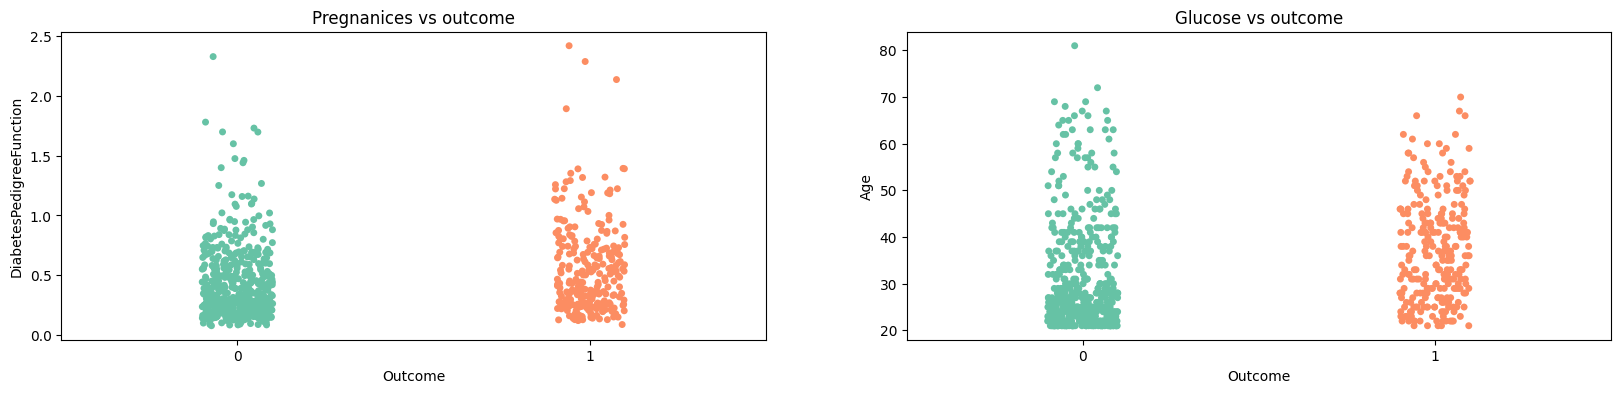

In [48]:
fig = plt.figure(figsize = [20,4]) 

plt.subplot(1,2,1) 
sns.stripplot(x = 'Outcome', y = 'DiabetesPedigreeFunction', data = data, jitter = True, palette = "Set2" ) 
plt.title('Pregnanices vs outcome') 

plt.subplot(1,2,2) 
sns.stripplot(x = 'Outcome', y = 'Age', data = data, jitter = True, palette = "Set2" ) 
plt.title('Glucose vs outcome') 

In [49]:
data_ = data.copy() 
zero_col = ['Glucose', 'Insulin', 'SkinThickness', 'BloodPressure', 'BMI'] 
data[zero_col] = data[zero_col].replace(0, np.nan)

In [50]:
data.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [58]:
for col in ['Glucose' , 'Insulin', 'SkinThickness']:
    median_col = np.median(data[data[col].notna()][col]) 
    data[col] = data[col].fillna(median_col) 
for col in ['BMI', 'BloodPressure']:
    mean_col = np.mean(data[data[col].notna()][col]) 
    data[col] = data[col].fillna(mean_col)

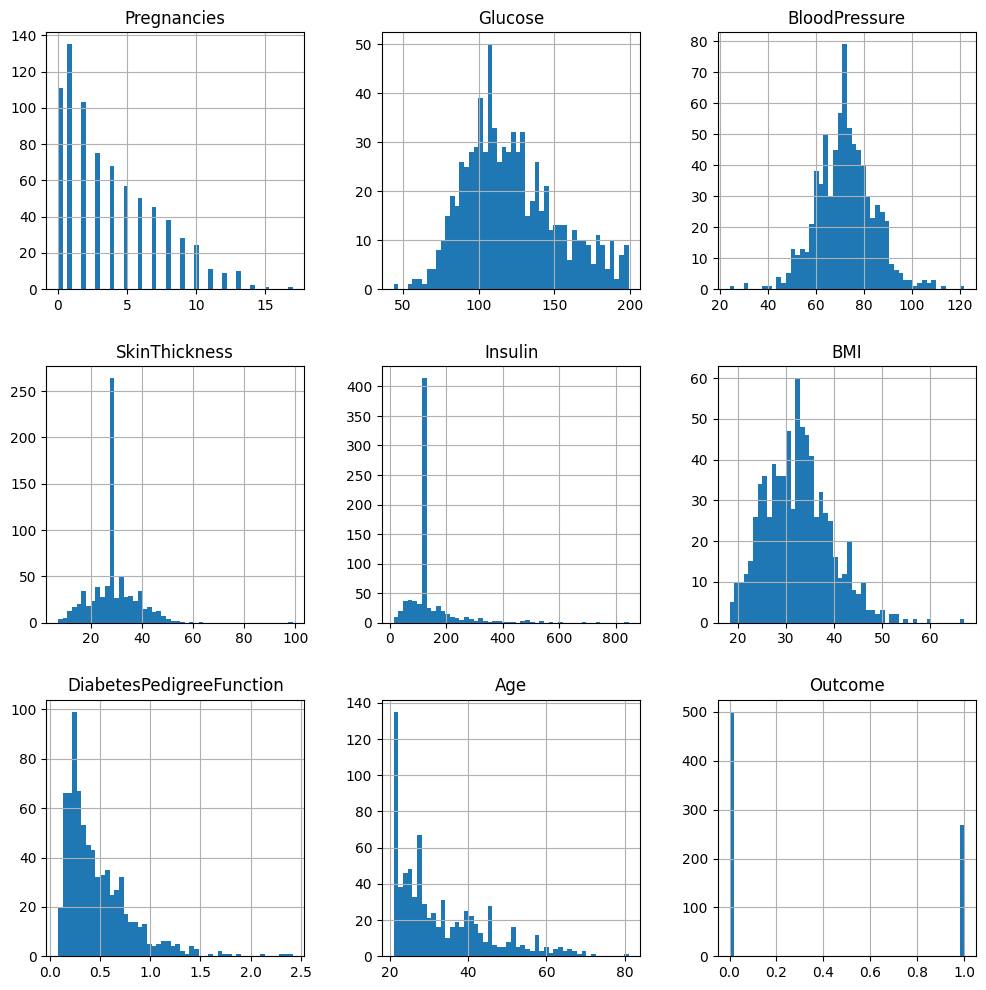

In [61]:
data.hist(bins = 50, figsize = (12,12)) 
plt.show()

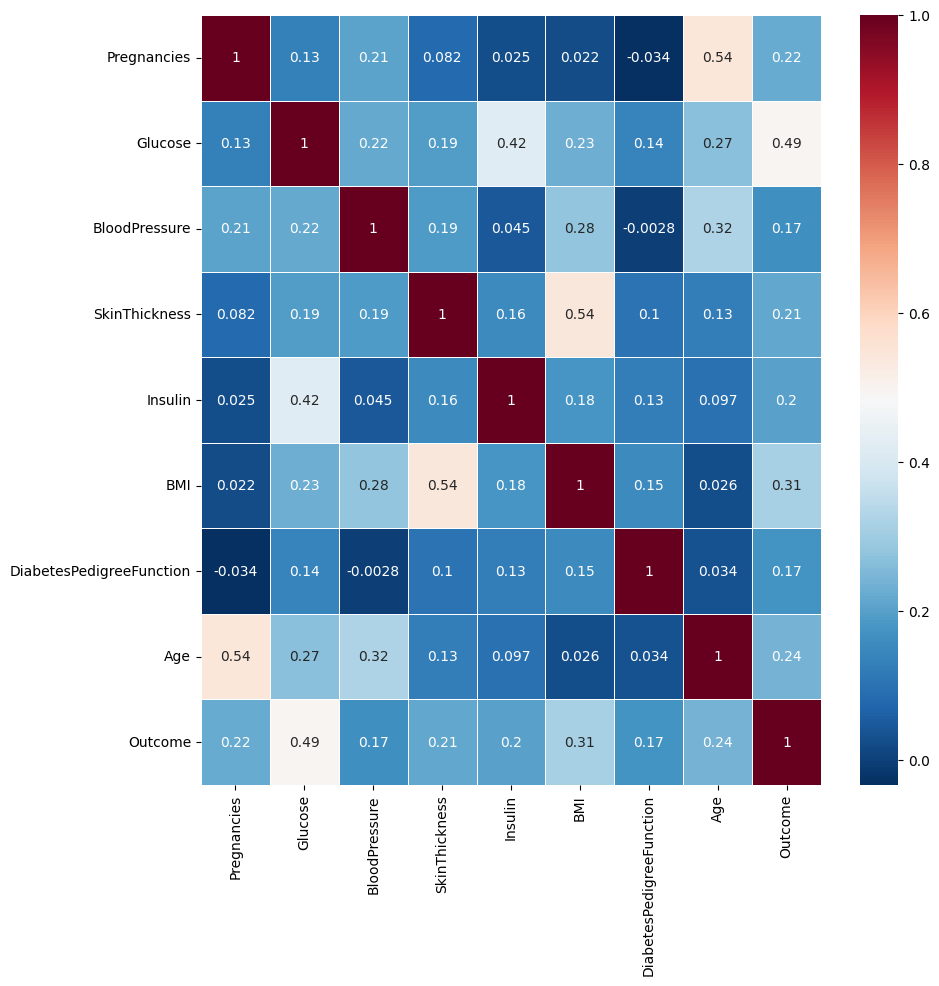

In [62]:
fig, ax = plt.subplots(figsize = (10,10)) 
x = sns.heatmap(data.corr(), cmap = 'RdBu_r', cbar = True, annot = True, linewidths = 0.5, ax = ax)
plt.show()

# ML Model Building

In [63]:
X = data.drop('Outcome', axis = 1) 
y = data['Outcome']

In [64]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [65]:
from sklearn.linear_model import LogisticRegression 
Logreg = LogisticRegression(solver = "liblinear") 
Logreg.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [67]:
y_pred = Logreg.predict(x_test)

In [68]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [69]:
Logreg.classes_

array([0, 1])

In [70]:
Logreg.intercept_

array([-5.55470044])

In [71]:
Logreg.coef_

array([[ 7.08861901e-02,  2.91888281e-02, -3.00832714e-02,
         3.50810391e-04, -1.10559043e-03,  7.05221569e-02,
         3.98474551e-01,  2.59628057e-02]])

In [72]:
Logreg.predict_proba(X)

array([[0.30657608, 0.69342392],
       [0.90851897, 0.09148103],
       [0.26069857, 0.73930143],
       ...,
       [0.7731148 , 0.2268852 ],
       [0.56390043, 0.43609957],
       [0.89434082, 0.10565918]], shape=(768, 2))

# Model Prediction

In [73]:
Logreg.score(X,y)

0.7669270833333334

# Model Evaluation: Cost Function

In [77]:
from sklearn.metrics import log_loss 
log_loss_value = log_loss(y_test, y_pred) 
print(f"Log Loss: {log_loss_value:.4f}")

Log Loss: 7.9577
